# Experiments with hierarchical structure of text content

In [1]:
import json
import re

# 1. Load your OCR JSON
ocr_filename  = '../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout_merged2.json'

with open(ocr_filename, "r", encoding="utf-8") as f:
    ocr_data = json.load(f)


In [2]:
def print_keys(data, indent=0):
    """
    Recursively print keys from a nested dictionary (and lists) with hierarchical indentation.
    """
    prefix = " " * indent
    if isinstance(data, dict):
        for key, value in data.items():
            print(f"{prefix}{key}")
            print_keys(value, indent + 2)
    elif isinstance(data, list):
        for item in data:
            print_keys(item, indent)

def print_top_keys(data):
    if isinstance(data, dict):
        for key in data.keys():
            print(key)
    else:
        print("Not a dictionary")

#print_keys(ocr_data, indent=2)
print_top_keys(ocr_data)

apiVersion
modelId
stringIndexType
content
pages
tables
paragraphs
keyValuePairs
styles
languages
contentFormat
sections
figures
mergedKeyValuePairs


In [3]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import numpy as np

# Load the Sentence-BERT model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Sample list of texts from your document sections or paragraphs
texts = [
    "This is the introduction of the document, providing an overview of the study.",
    "The methodology section explains the data collection and analysis process.",
    "Results show significant improvement in performance after applying the algorithm.",
    "In the discussion, we compare our findings with related work in the field."
]

# Generate embeddings for each text
embeddings = model.encode(texts, show_progress_bar=True)

# Print the embeddings
for text, embedding in zip(texts, embeddings):
    print(f"Text: {text}")
    print(f"Embedding: {embedding[:10]}...")  # Print first 10 dimensions for brevity
    print()

# Compute cosine similarity matrix
cos_sim_matrix = cosine_similarity(embeddings)
print("Cosine Similarity Matrix:")
print(cos_sim_matrix)

# Compute Euclidean distance matrix
euclidean_matrix = euclidean_distances(embeddings)
print("\nEuclidean Distance Matrix:")
print(euclidean_matrix)

# Example: Distance between first and second text
print("\nCosine similarity between text 0 and text 1:", cos_sim_matrix[0][1])
print("Euclidean distance between text 0 and text 1:", euclidean_matrix[0][1])

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Text: This is the introduction of the document, providing an overview of the study.
Embedding: [-0.00559058  0.088334    0.00694797  0.07140665 -0.05149508  0.06170814
 -0.04764654  0.13979359 -0.05198829  0.0203247 ]...

Text: The methodology section explains the data collection and analysis process.
Embedding: [-0.0104163   0.05293079 -0.11374742 -0.00872538  0.00608292 -0.04338054
 -0.07721034  0.02532059 -0.04444307  0.02908137]...

Text: Results show significant improvement in performance after applying the algorithm.
Embedding: [ 0.02957356  0.07892517  0.00616034 -0.04892756 -0.04271282 -0.07028975
 -0.03516496  0.00915298 -0.0744353  -0.05780991]...

Text: In the discussion, we compare our findings with related work in the field.
Embedding: [-0.06938256  0.01839469 -0.03977845  0.00192981  0.04704428  0.00106177
 -0.00266044  0.06965948  0.03450458 -0.03785924]...

Cosine Similarity Matrix:
[[1.         0.44069102 0.0717814  0.441912  ]
 [0.44069102 1.         0.2357136  0.3431

In [4]:
import json
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

def load_ocr_json(file_path):
    """Load the OCR JSON from a file."""
    with open(file_path, "r", encoding="utf-8") as f:
        return json.load(f)

def extract_paragraph_texts(ocr_data):
    """
    Extract text and identifiers from the OCR paragraphs.
    You could similarly extract table text or combine them using the 
    'sections' key that points to pointers like "/paragraphs/0", etc.
    """
    paragraphs = ocr_data.get("paragraphs", [])
    texts = []
    ids = []
    for idx, para in enumerate(paragraphs):
        # Get the 'content' field from each paragraph.
        text = para.get("content", "").strip()
        if text:  # Skip empty ones if desired
            texts.append(text)
            ids.append(idx)
    return ids, texts

def cluster_texts(texts, num_clusters=5):
    """
    Compute embeddings for each text using Sentence-BERT and cluster them using KMeans.
    Adjust num_clusters based on your data and domain.
    """
    # Load a pre-trained Sentence-BERT model (e.g., "all-MiniLM-L6-v2")
    model = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = model.encode(texts, show_progress_bar=True)

    # Use KMeans to cluster embeddings
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    labels = kmeans.fit_predict(embeddings)
    return labels, embeddings


# Path to your OCR JSON file
#ocr_file = "ocr_output.json"

# Load the OCR data
#ocr_data = load_ocr_json(ocr_file)

# Extract paragraph texts (or combine text from other elements as needed)
ids, texts = extract_paragraph_texts(ocr_data)

# Cluster the texts (adjust the number of clusters as needed)
num_clusters = 5  # For example, you might expect five key semantic chunks
labels, embeddings = cluster_texts(texts, num_clusters=num_clusters)

# Print out each paragraph with its assigned cluster label
for pid, text, label in zip(ids, texts, labels):
    print(f"Paragraph {pid} (Cluster {label}): {text}\n")


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Paragraph 0 (Cluster 4): MARKETING RESEARCH AUTHORIZATIU .. (Recommended Proposal Attached)

Paragraph 1 (Cluster 3): Date: 4/16/90

Paragraph 2 (Cluster 1): Description: Y-1 Ultra 100's vs. Winston Ultra 100's

Paragraph 3 (Cluster 1): Requested By: W. T. Carpenter

Paragraph 4 (Cluster 0): No. 6

Paragraph 5 (Cluster 4): Research

Paragraph 6 (Cluster 0): Request Attached:

Paragraph 7 (Cluster 2): Yes :selected: No
:unselected:

Paragraph 8 (Cluster 0): Budgeted:

Paragraph 9 (Cluster 2): Yes :selected: No
:unselected:

Paragraph 10 (Cluster 0): Original

Paragraph 11 (Cluster 0): Budgeted Amount 23.3

Paragraph 12 (Cluster 4): Competitive Proposals Obtained: Est. Cost Per Supplier Cost ($) Travel Total Cost Interview

Paragraph 13 (Cluster 0): Kapuler

Paragraph 14 (Cluster 0): $33.675 +10%Est.

Paragraph 15 (Cluster 0): $2000

Paragraph 16 (Cluster 2): :selected: $35,675

Paragraph 17 (Cluster 0): $84.2

Paragraph 18 (Cluster 4): Market Facts

Paragraph 19 (Cluster 0): $35.000 +10

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [14]:
import json
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import SpectralClustering

def load_ocr_json(file_path):
    """Load OCR JSON from file."""
    with open(file_path, "r", encoding="utf-8") as f:
        return json.load(f)

def extract_paragraphs(ocr_data):
    """
    Extract paragraph texts and bounding boxes.
    Here, we assume each paragraph has a "content" string and a list of "boundingRegions".
    We take the first bounding region and compute its center.
    Returns lists of texts and centers (as [x_center, y_center]).
    """
    paragraphs = ocr_data.get("paragraphs", [])
    texts = []
    centers = []
    
    for para in paragraphs:
        text = para.get("content", "").strip()
        if not text:
            continue

        # Use the first bounding region to compute the center.
        brs = para.get("boundingRegions", [])
        if not brs:
            continue
        # Each bounding region has a "polygon" of points: [x1, y1, x2, y2, ..., xN, yN]
        # We'll assume the polygon is rectangular and compute center from min/max.
        poly = brs[0].get("polygon", [])
        if not poly or len(poly) < 4:
            continue

        # Convert polygon list into pairs:
        pts = np.array(poly).reshape(-1, 2)
        x_min, y_min = pts.min(axis=0)
        x_max, y_max = pts.max(axis=0)
        center = [(x_min + x_max) / 2, (y_min + y_max) / 2]

        texts.append(text)
        centers.append(center)
    return texts, np.array(centers)

def compute_spatial_similarity(centers, sigma=50.0):
    """
    Compute spatial similarity matrix given the centers of paragraphs.
    We use a Gaussian kernel: sim(i, j) = exp(-||center_i - center_j||^2 / (2 * sigma^2))
    sigma should be set according to the scale of your coordinates.
    """
    num = centers.shape[0]
    sim = np.zeros((num, num))
    for i in range(num):
        for j in range(num):
            dist = np.linalg.norm(centers[i] - centers[j])
            sim[i, j] = np.exp(- (dist ** 2) / (2 * sigma ** 2))
    return sim

def compute_text_similarity(texts, model):
    """Compute cosine similarity between paragraph embeddings."""
    embeddings = model.encode(texts, show_progress_bar=True)
    return cosine_similarity(embeddings), embeddings

def composite_similarity(text_sim, spatial_sim, alpha=0.7):
    """
    Combine text and spatial similarities.
    alpha: weight for text similarity, (1-alpha) for spatial.
    """
    return alpha * text_sim + (1 - alpha) * spatial_sim

def cluster_paragraphs(affinity, n_clusters=5):
    """
    Cluster paragraphs using Spectral Clustering with a precomputed affinity matrix.
    """
    sc = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=42)
    return sc.fit_predict(affinity)

# Load OCR data from file (adjust file path accordingly)
#ocr_file = "ocr_output.json"
#ocr_data = load_ocr_json(ocr_file)

# Extract paragraph texts and bounding box centers
texts, centers = extract_paragraphs(ocr_data)
if not texts:
    print("No paragraphs found!")
else:

    # Load Sentence-BERT model
    model = SentenceTransformer("all-MiniLM-L6-v2")

    # Compute text similarity matrix
    text_sim, embeddings = compute_text_similarity(texts, model)

    # Compute spatial similarity matrix (sigma is a tuning parameter)
    spatial_sim = compute_spatial_similarity(centers, sigma=50.0)

    # Combine similarities: alpha controls weighting (0 <= alpha <= 1)
    alpha = 0.3  # Higher weight for text similarity
    affinity = composite_similarity(text_sim, spatial_sim, alpha=alpha)

    # Cluster paragraphs using the composite similarity matrix.
    n_clusters = 8  # Adjust as needed based on your document
    labels = cluster_paragraphs(affinity, n_clusters=n_clusters)

    # Print paragraphs with their cluster labels
    # create a cluster label list for paragraphs
    cluster_labels = []
    for i, (text, center, label) in enumerate(zip(texts, centers, labels)):
        cluster_labels.append(label.item())
        print(f"Paragraph {i} (Cluster {label}, Center: {center}):")
        print(text)
        print("-" * 80)




Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Paragraph 0 (Cluster 3, Center: [352.   55.5]):
MARKETING RESEARCH AUTHORIZATIU .. (Recommended Proposal Attached)
--------------------------------------------------------------------------------
Paragraph 1 (Cluster 7, Center: [130.   76.5]):
Date: 4/16/90
--------------------------------------------------------------------------------
Paragraph 2 (Cluster 3, Center: [263. 104.]):
Description: Y-1 Ultra 100's vs. Winston Ultra 100's
--------------------------------------------------------------------------------
Paragraph 3 (Cluster 0, Center: [184.5 131.5]):
Requested By: W. T. Carpenter
--------------------------------------------------------------------------------
Paragraph 4 (Cluster 0, Center: [514.5  76.5]):
No. 6
--------------------------------------------------------------------------------
Paragraph 5 (Cluster 3, Center: [338.  123.5]):
Research
--------------------------------------------------------------------------------
Paragraph 6 (Cluster 0, Center: [435.5 122.5]):
R

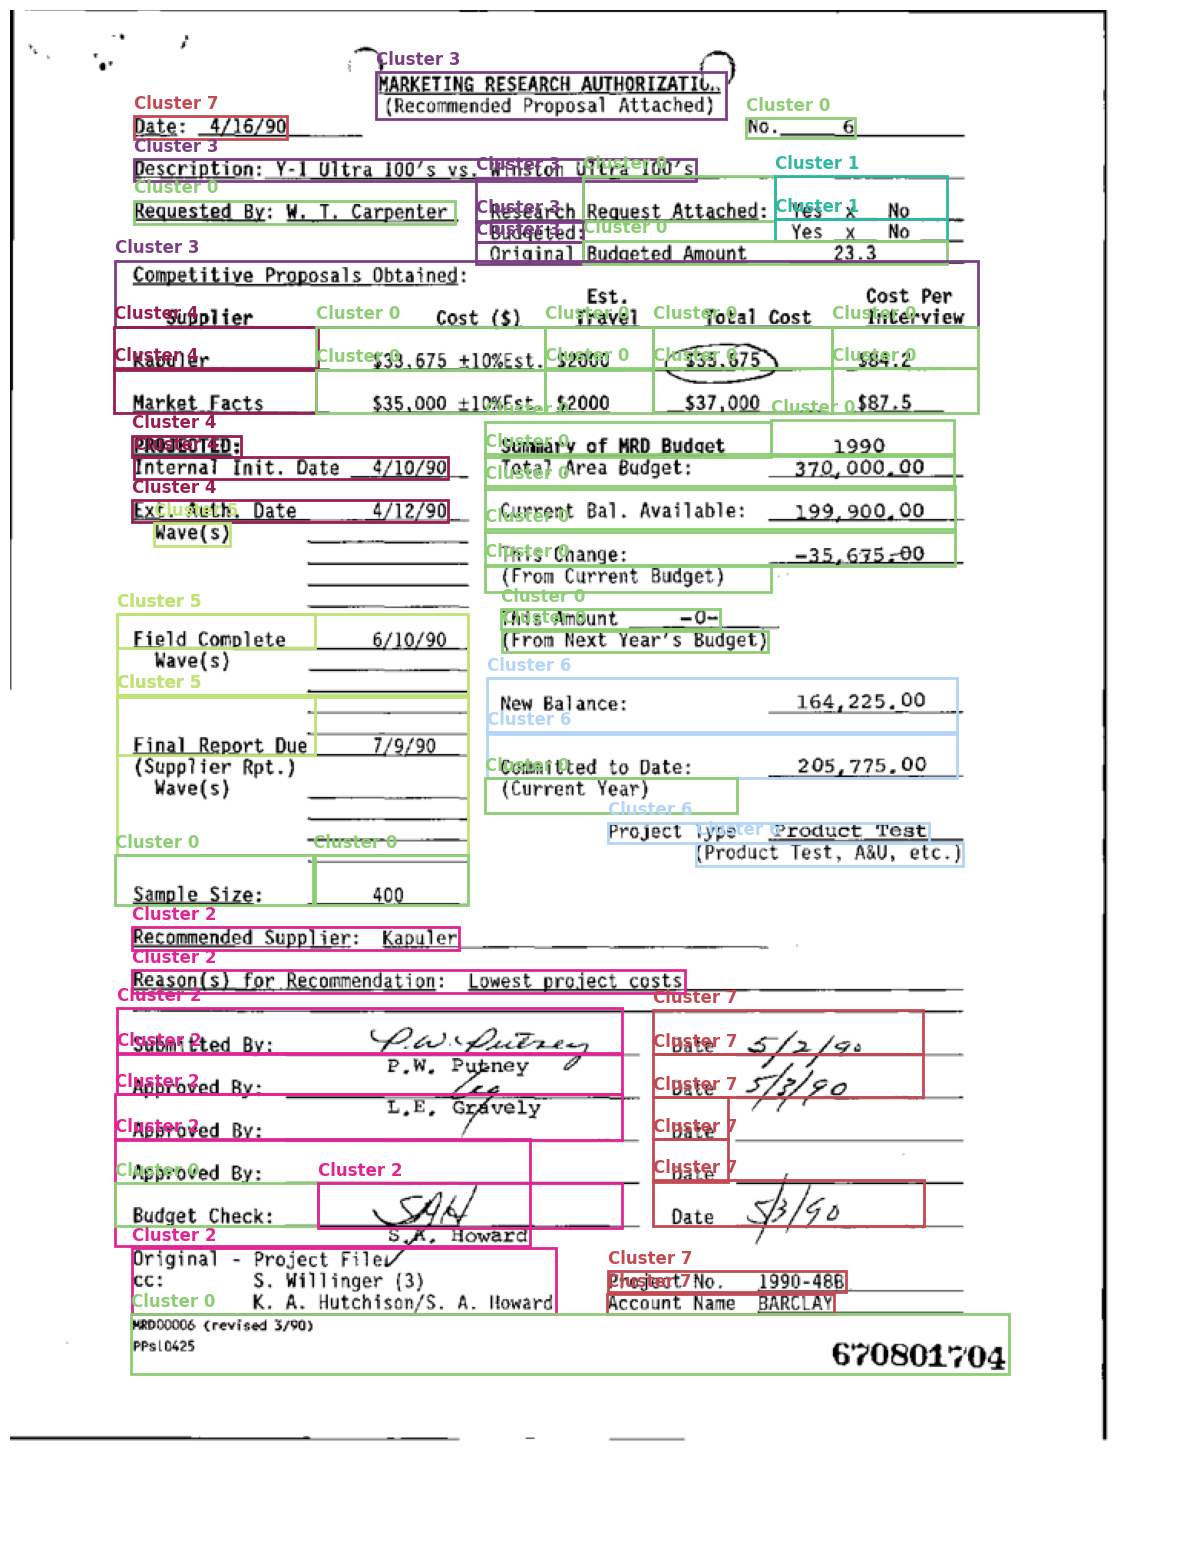

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from random import randint

def polygon_to_bbox(polygon):
    """
    Given a polygon as a list of points (each point a dict with x, y),
    compute the bounding box [x_min, y_min, x_max, y_max].
    """
    #xs = [pt["x"] for pt in polygon]
    #ys = [pt["y"] for pt in polygon]
    # Assume polygon is a flat list of numbers: [x1, y1, x2, y2, ...]
    pts = np.array(polygon).reshape(-1, 2)
    xs = pts[:, 0]
    ys = pts[:, 1]

    return [min(xs), min(ys), max(xs), max(ys)]

def plot_paragraph_boxes(image_path, paragraphs, labels):
    """
    image_path: path to the document image.
    paragraphs: a list of paragraph objects from OCR data.
      Each paragraph is assumed to have a 'boundingRegions' key containing a list of regions,
      and we use the first region's 'polygon' to compute the bounding box.
    labels: a list of cluster labels corresponding to each paragraph.
    """
    # Read the image (OpenCV reads as BGR)
    img = cv2.imread(image_path)
    if img is None:
        print("Could not load image.")
        return

    # Convert image to RGB for matplotlib.
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Create a matplotlib figure
    fig, ax = plt.subplots(1, figsize=(12, 16))
    ax.imshow(img_rgb)

    # Generate a color map for clusters. We'll create one color per unique label.
    unique_labels = sorted(set(labels))
    cmap = {}
    for lbl in unique_labels:
        # Random color: you can also use a predefined colormap.
        cmap[lbl] = (randint(0,255)/255.0, randint(0,255)/255.0, randint(0,255)/255.0)
    
    # Loop over paragraphs and plot bounding boxes.
    for para, lbl in zip(paragraphs, labels):
        #print(para)
        brs = para.get("boundingRegions", [])
        #print(brs)
        if not brs:
            continue
        # Use the first bounding region for plotting.
        poly = brs[0].get("polygon", [])
        #print(poly)
        if len(poly) < 4:
            continue
        
        bbox = polygon_to_bbox(poly)
        x_min, y_min, x_max, y_max = bbox
        width, height = x_max - x_min, y_max - y_min
        
        # Create a rectangle patch with the cluster color.
        rect = patches.Rectangle((x_min, y_min), width, height, linewidth=2,
                                 edgecolor=cmap[lbl], facecolor='none')
        ax.add_patch(rect)
        # Optionally, add the cluster label as text
        ax.text(x_min, y_min - 5, f"Cluster {lbl}", color=cmap[lbl],
                fontsize=12, weight='bold')
    
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# Example usage:
# Load OCR data (assumed to be a dictionary from your OCR JSON)
#with open("ocr_output.json", "r", encoding="utf-8") as f:
#    ocr_data = json.load(f)

# Extract paragraphs from OCR data. (This assumes a similar structure as provided.)
paragraphs = ocr_data.get("paragraphs", [])

# For demonstration, let's assume you have computed cluster labels for each paragraph.
# For instance, here we assign a random cluster label (in practice, use your clustering results).
#np.random.seed(42)
#labels = [np.random.randint(0, 5) for _ in range(len(paragraphs))]

# Path to your document image
image_path = '../datasets/FUNSD/training_data/images/0001463282.png'

# Plot the bounding boxes with cluster labels.
plot_paragraph_boxes(image_path, paragraphs, cluster_labels)

In [16]:
import json
import numpy as np

def polygon_to_bbox(polygon):
    """
    Convert a polygon into a bounding box [x_min, y_min, x_max, y_max].
    If the polygon is a list of dictionaries (with "x", "y"), use those;
    otherwise, assume it is a flat list of numbers.
    """
    # if isinstance(polygon[0], dict):
    #     xs = [pt["x"] for pt in polygon]
    #     ys = [pt["y"] for pt in polygon]
    # else:
    pts = np.array(polygon).reshape(-1, 2)
    xs = pts[:, 0]
    ys = pts[:, 1]
    return [min(xs), min(ys), max(xs), max(ys)]

def get_paragraph_top(para):
    """
    Given a paragraph object, extract the top coordinate (y_min)
    from the first bounding region.
    """
    brs = para.get("boundingRegions", [])
    if not brs:
        return float('inf')
    poly = brs[0].get("polygon", [])
    if not poly:
        return float('inf')
    bbox = polygon_to_bbox(poly)
    return bbox[1]  # y_min

def group_paragraphs_by_cluster(paragraphs, labels):
    """
    Group paragraphs by cluster and order them by their vertical position.
    
    paragraphs: list of paragraph objects (from OCR JSON)
    labels: list of cluster labels (one per paragraph)
    
    Returns a dictionary where keys are cluster labels and values are lists
    of paragraph texts in reading order.
    """
    # Group paragraphs by cluster
    cluster_dict = {}
    for para, lbl in zip(paragraphs, labels):
        if lbl not in cluster_dict:
            cluster_dict[lbl] = []
        cluster_dict[lbl].append(para)
    
    # Sort paragraphs within each cluster by their top coordinate (and optionally x_min)
    cluster_texts = {}
    for lbl, paras in cluster_dict.items():
        # Sort by vertical position (y_min); optionally, add horizontal (x_min) as tiebreaker
        paras_sorted = sorted(
            paras,
            key=lambda p: (
                get_paragraph_top(p),
                polygon_to_bbox(p.get("boundingRegions", [])[0]["polygon"])[0]
                    if p.get("boundingRegions", []) else 0
            )
        )
        # Combine the text of paragraphs in order.
        cluster_texts[lbl] = "\n".join(p.get("content", "").strip() for p in paras_sorted)
    return cluster_texts

# Load OCR data (this assumes you have an OCR JSON file with a "paragraphs" key)
#with open("ocr_output.json", "r", encoding="utf-8") as f:
#    ocr_data = json.load(f)

paragraphs = ocr_data.get("paragraphs", [])

# Assume you already have computed cluster labels for each paragraph.
# For demonstration, here we simulate labels (replace with your clustering results).
# For example, assign cluster 0 for even indices and 1 for odd indices:
#labels = [0 if i % 2 == 0 else 1 for i in range(len(paragraphs))]

# Group and sort paragraphs by cluster
clusters = group_paragraphs_by_cluster(paragraphs, cluster_labels)

# Print the aggregated text for each cluster in order.
for cluster_label in sorted(clusters.keys()):
    print(f"Cluster {cluster_label}:")
    print(clusters[cluster_label])
    print("="*80)


Cluster 0:
No. 6
Request Attached:
Requested By: W. T. Carpenter
Budgeted Amount 23.3
$33.675 +10%Est.
$2000
:selected: $35,675
$84.2
$2000
$37,000
$87.5
$35.000 +10%Est.
1990
Summary of MRD Budget
Total Area Budget: 370,000.00
Current Bal. Available: 199,900.00
This Change: -35,675.00
(From Current Budget)
This Amount -0-
(From Next Year's Budget)
(Current Year)
Sample Size:
400
Budget Check:
MRD00006 (revised 3/90) PPS10425 670801704
Cluster 1:
Yes :selected: No
:unselected:
Yes :selected: No
:unselected:
Cluster 2:
Recommended Supplier: Kapuler
Reason(s) for Recommendation: Lowest project costs
Submitted By: P.W. Dutrey
Approved By: P. W. Putney
Approved By: L. E, Gravely
Approved By: S. R. Howard
SAN
Original - Project Filev CC: S. Willinger (3) K. A. Hutchison/S. A. Howard
Cluster 3:
MARKETING RESEARCH AUTHORIZATIU .. (Recommended Proposal Attached)
Description: Y-1 Ultra 100's vs. Winston Ultra 100's
Research
Budgeted:
Original
Competitive Proposals Obtained: Est. Cost Per Suppli

In [17]:
from openai import OpenAI
import json
import os

# Make sure your OpenAI API key is set in your environment:
# export OPENAI_API_KEY="your_api_key_here"

def get_semantic_designation(cluster_text):
    """
    Uses GPT‑4 via ChatCompletion to determine a semantic designation for the given cluster text.
    Returns the designation as a string.
    """
    prompt = (
        "You are a helpful assistant that assigns a semantic designation to a document text cluster. "
        "Based on the text provided, please output a one- or two-word designation that best describes "
        "the key concept of the text (for example: 'Title', 'Introduction', 'Methodology', 'Results', "
        "'Conclusion', etc.).\n\n"
        "Cluster Text:\n" + cluster_text + "\n\n"
        "Semantic Designation:"
    )

    client = OpenAI(
        api_key=os.environ.get("OPENAI_API_KEY"),  # This is the default and can be omitted
    )
    
    response = client.chat.completions.create(
        messages=[
            {"role": "system", "content": "You are an expert in document analysis."},
            {"role": "user", "content": prompt}
        ],
        model="gpt-4o",
        temperature=0.3,
        max_tokens=30
    )
    
    # Extract the generated designation from the response.
    designation = response.choices[0].message.content.strip()
    return designation


# For demonstration, assume this dictionary is the output from your clustering process.
# clusters = {
#     0: (
#         "This section provides an overview of the document, including a summary of key "
#         "background information and the main objective of the research proposal."
#     ),
#     1: (
#         "This section details the methodology used in the study, including experimental design, "
#         "data collection techniques, and analysis methods."
#     ),
#     2: (
#         "In this section, the experimental results are presented along with supporting tables and "
#         "figures that illustrate the key findings of the study."
#     ),
#     3: (
#         "This section contains concluding remarks and a discussion of the implications of the results, "
#         "as well as suggestions for future work."
#     )
#}

semantic_designations = {}
for label, text in clusters.items():
    designation = get_semantic_designation(text)
    semantic_designations[label] = designation
    print(f"Cluster {label} is designated as: {designation}\n")

# Optionally, save the designations to a file.
with open("cluster_semantic_designations.json", "w", encoding="utf-8") as f:
    json.dump(semantic_designations, f, indent=2)


Cluster 3 is designated as: Budget

Cluster 7 is designated as: Metadata

Cluster 0 is designated as: Budget Summary

Cluster 1 is designated as: Selection

Cluster 4 is designated as: Project Timeline

Cluster 5 is designated as: Schedule

Cluster 6 is designated as: Financial Summary

Cluster 2 is designated as: Approval



In [39]:
import os
import json
import numpy as np

def polygon_to_bbox(polygon):
    """
    Convert a flat polygon array into a bounding box [x_min, y_min, x_max, y_max].
    The polygon is expected to be a flat list of numbers: [x1, y1, x2, y2, ...].
    """
    pts = np.array(polygon).reshape(-1, 2)
    x_min = float(pts[:, 0].min())
    y_min = float(pts[:, 1].min())
    x_max = float(pts[:, 0].max())
    y_max = float(pts[:, 1].max())
    return [x_min, y_min, x_max, y_max]

def union_bbox(bbox_list):
    """
    Given a list of bounding boxes [x_min, y_min, x_max, y_max],
    compute the union bounding box that encloses all of them.
    """
    if not bbox_list:
        return None
    xmins = [bbox[0] for bbox in bbox_list]
    ymins = [bbox[1] for bbox in bbox_list]
    xmaxs = [bbox[2] for bbox in bbox_list]
    ymaxs = [bbox[3] for bbox in bbox_list]
    return [min(xmins), min(ymins), max(xmaxs), max(ymaxs)]

def merge_key_value_pairs(ocr_json):
    """
    For each keyValuePair in the OCR JSON, merge the key and value:
      - Concatenate the text contents.
      - Compute a union bounding box from the key and value bounding regions.
    The result is stored in a new "mergedKeyValuePairs" key in the OCR JSON.
    """
    merged = []
    for kv in ocr_json.get("keyValuePairs", []):
        key = kv.get("key", {})
        value = kv.get("value", {})
        
        key_text = key.get("content", "").strip()
        value_text = value.get("content", "").strip()
        merged_text = key_text + " " + value_text
        
        # Collect bounding boxes from key and value regions.
        bbox_list = []
        for region in key.get("boundingRegions", []):
            poly = region.get("polygon", [])
            if poly:
                bbox_list.append(polygon_to_bbox(poly))
        for region in value.get("boundingRegions", []):
            poly = region.get("polygon", [])
            if poly:
                bbox_list.append(polygon_to_bbox(poly))
        merged_bbox = union_bbox(bbox_list)
        
        # Use the pageNumber from the first available bounding region.
        pageNumber = None
        if key.get("boundingRegions"):
            pageNumber = key["boundingRegions"][0].get("pageNumber")
        elif value.get("boundingRegions"):
            pageNumber = value["boundingRegions"][0].get("pageNumber")
        
        merged_region = {"pageNumber": pageNumber, "polygon": merged_bbox} if merged_bbox else {}
        
        merged.append({
            "content": merged_text,
            "boundingRegion": merged_region,
            # Optionally, keep the original key-value pair for reference:
            "originalKeyValuePair": kv
        })
    
    # Write the merged key-value pairs into a new key in the OCR JSON.
    ocr_json["mergedKeyValuePairs"] = merged
    return ocr_json

# Path to your OCR JSON file
#input_path = "ocr_output.json"   # Replace with your actual input path
output_path = '../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout_merged.json'

# Load the OCR JSON
# with open(input_path, "r", encoding="utf-8") as f:
#     ocr_data = json.load(f)

# Merge the key-value pairs
modified_ocr = merge_key_value_pairs(ocr_data)

# Write the modified OCR JSON to a file
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(modified_ocr, f, indent=2)

print(f"Modified OCR JSON with merged key-value pairs written to {output_path}")


Modified OCR JSON with merged key-value pairs written to ../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout_merged.json


In [4]:
import os
import json
import numpy as np

def polygon_to_bbox(polygon):
    """
    Convert a flat polygon array into a bounding box [x_min, y_min, x_max, y_max].
    The polygon is expected to be a flat list of numbers: [x1, y1, x2, y2, ...].
    """
    pts = np.array(polygon).reshape(-1, 2)
    x_min = float(pts[:, 0].min())
    y_min = float(pts[:, 1].min())
    x_max = float(pts[:, 0].max())
    y_max = float(pts[:, 1].max())
    return [x_min, y_min, x_max, y_max]

def union_bbox(bbox_list):
    """
    Given a list of bounding boxes [x_min, y_min, x_max, y_max],
    compute the union bounding box that encloses all of them.
    """
    if not bbox_list:
        return None
    xmins = [bbox[0] for bbox in bbox_list]
    ymins = [bbox[1] for bbox in bbox_list]
    xmaxs = [bbox[2] for bbox in bbox_list]
    ymaxs = [bbox[3] for bbox in bbox_list]
    return [min(xmins), min(ymins), max(xmaxs), max(ymaxs)]

def compute_iou(bbox1, bbox2):
    """
    Compute Intersection over Union (IoU) between two bounding boxes.
    Each bbox is in the form [x_min, y_min, x_max, y_max].
    """
    xA = max(bbox1[0], bbox2[0])
    yA = max(bbox1[1], bbox2[1])
    xB = min(bbox1[2], bbox2[2])
    yB = min(bbox1[3], bbox2[3])
    
    interW = max(0, xB - xA)
    interH = max(0, yB - yA)
    interArea = interW * interH
    
    box1Area = (bbox1[2]-bbox1[0]) * (bbox1[3]-bbox1[1])
    box2Area = (bbox2[2]-bbox2[0]) * (bbox2[3]-bbox2[1])
    
    unionArea = box1Area + box2Area - interArea
    if unionArea == 0:
        return 0
    return interArea / unionArea

def get_paragraph_bbox(para):
    """
    Compute the union bounding box for a paragraph by combining all its boundingRegions.
    Assumes each region has a flat polygon array under "polygon".
    """
    bboxes = []
    for region in para.get("boundingRegions", []):
        poly = region.get("polygon", [])
        if poly:
            bboxes.append(polygon_to_bbox(poly))
    if bboxes:
        return union_bbox(bboxes)
    return None

def merge_key_value_pairs_in_paragraphs(ocr_json, iou_threshold=0.1):
    """
    For each keyValuePair in the OCR JSON, find the paragraph that best matches the key and
    the paragraph that best matches the value (using IoU on bounding boxes). Then update the key paragraph:
      - Append the value text to the key text.
      - Update the paragraph's boundingRegions with the union of the key and value bounding boxes.
    Finally, remove the paragraph corresponding to the value.
    
    Returns the modified OCR JSON.
    """
    paragraphs = ocr_json.get("paragraphs", [])
    # Keep track of indices to remove (value paragraphs)
    remove_indices = set()

    for kv in ocr_json.get("keyValuePairs", []):
        # Compute union bbox for key and for value
        key_regions = kv.get("key", {}).get("boundingRegions", [])
        value_regions = kv.get("value", {}).get("boundingRegions", [])
        if not key_regions or not value_regions:
            continue
        
        key_bboxes = [polygon_to_bbox(r.get("polygon", [])) for r in key_regions if r.get("polygon")]
        value_bboxes = [polygon_to_bbox(r.get("polygon", [])) for r in value_regions if r.get("polygon")]
        if not key_bboxes or not value_bboxes:
            continue
        
        key_bbox = union_bbox(key_bboxes)
        value_bbox = union_bbox(value_bboxes)
        
        # For each paragraph, compute its bbox and then IoU with key_bbox and value_bbox.
        best_key_iou = 0
        best_key_idx = None
        best_value_iou = 0
        best_value_idx = None

        for idx, para in enumerate(paragraphs):
            para_bbox = get_paragraph_bbox(para)
            if para_bbox is None:
                continue
            iou_key = compute_iou(key_bbox, para_bbox)
            iou_value = compute_iou(value_bbox, para_bbox)
            if iou_key > best_key_iou:
                best_key_iou = iou_key
                best_key_idx = idx
            if iou_value > best_value_iou:
                best_value_iou = iou_value
                best_value_idx = idx

        # Only update if both key and value paragraphs were found
        if best_key_idx is not None and best_value_idx is not None and best_key_idx != best_value_idx:
            # Optionally, require a minimum IoU to be sure they match
            if best_key_iou >= iou_threshold and best_value_iou >= iou_threshold:
                key_para = paragraphs[best_key_idx]
                value_para = paragraphs[best_value_idx]
                
                # Update key paragraph: append value content (if not already present)
                key_text = key_para.get("content", "").strip()
                value_text = value_para.get("content", "").strip()
                # For safety, check if value_text is already a substring
                if value_text and value_text not in key_text:
                    merged_text = key_text + " " + value_text
                else:
                    merged_text = key_text

                key_para["content"] = merged_text
                
                # Update boundingRegions: union the bounding boxes.
                key_bbox_existing = get_paragraph_bbox(key_para)
                value_bbox_existing = get_paragraph_bbox(value_para)
                merged_bbox = union_bbox([key_bbox_existing, value_bbox_existing])
                # Replace boundingRegions with a single region using the merged bbox.
                # You may choose a different format if needed.
                key_para["boundingRegions"] = [{
                    "pageNumber": key_regions[0].get("pageNumber", None),
                    "polygon": merged_bbox  # Note: merged_bbox is a list [x_min, y_min, x_max, y_max]
                }]
                
                # Mark the value paragraph for removal.
                remove_indices.add(best_value_idx)
    
    # Remove paragraphs with indices in remove_indices, in reverse order.
    for idx in sorted(remove_indices, reverse=True):
        del paragraphs[idx]
    
    ocr_json["paragraphs"] = paragraphs
    return ocr_json

# Path to your OCR JSON file
#input_path = "ocr_output.json"   # Replace with your actual input path
output_path = '../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout_merged2.json'

# Load the OCR JSON
# with open(input_path, "r", encoding="utf-8") as f:
#     ocr_data = json.load(f)

# Merge the key-value pairs
modified_ocr = merge_key_value_pairs_in_paragraphs(ocr_data, iou_threshold=0.1)

# Write the modified OCR JSON to a file
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(modified_ocr, f, indent=2)

print(f"Modified OCR JSON with merged key-value pairs written to {output_path}")


Modified OCR JSON with merged key-value pairs written to ../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout_merged2.json
